# Linear Discriminant Analysis (LDA) and Fisher Score — From Scratch

_Generated: 2025-10-22T18:15:54.158737Z_

This notebook derives and implements **Fisher’s Linear Discriminant** and the **LDA classifier** using only NumPy. We also compute **Fisher scores** for feature ranking. The dataset is **Iris** (3 classes).

## 0) Environment & Dependencies

In [1]:
import sys, platform, subprocess
def _sh(cmd):
    try:
        out = subprocess.check_output(cmd, shell=True, stderr=subprocess.STDOUT, text=True)
    except Exception as e:
        out = f"[command failed] {e}"
    print(out)

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("In Colab:", "google.colab" in sys.modules)

!pip -q install --upgrade pip
!pip -q install numpy matplotlib scikit-learn

Python: 3.12.12
Platform: Linux-6.6.105+-x86_64-with-glibc2.35
In Colab: True
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 17.2 MB/s eta 0:00:00


## 1) Imports & Utilities

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

np.set_printoptions(precision=5, suppress=True)
SEED = 42
rng = np.random.default_rng(SEED)

def train_test_split(X, y, test_size=0.3, rng=rng):
    n = len(y); idx = np.arange(n); rng.shuffle(idx)
    n_te = int(round(test_size*n))
    te = idx[:n_te]; tr = idx[n_te:]
    return X[tr], X[te], y[tr], y[te]

def standardize(X, mean=None, std=None, eps=1e-12):
    if mean is None: mean = X.mean(axis=0)
    if std is None: std = X.std(axis=0)
    std = np.where(std < eps, 1.0, std)
    return (X-mean)/std, mean, std

def confusion_matrix(y_true, y_pred, n_classes=None):
    if n_classes is None: n_classes = int(np.max([y_true.max(), y_pred.max()])) + 1
    C = np.zeros((n_classes, n_classes), dtype=int)
    for t,p in zip(y_true, y_pred):
        C[int(t), int(p)] += 1
    return C

## 2) Data — Iris, Standardization

In [3]:
iris = datasets.load_iris()
X = iris.data.astype(float)
y = iris.target.astype(int)
feature_names = iris.feature_names
class_names = iris.target_names

X_std, mu, sigma = standardize(X)
X_tr, X_te, y_tr, y_te = train_test_split(X_std, y, test_size=0.3, rng=rng)

print("Train:", X_tr.shape, " Test:", X_te.shape)
print("Classes:", class_names)

Train: (105, 4)  Test: (45, 4)
Classes: ['setosa' 'versicolor' 'virginica']


## 3) Fisher’s Criterion and Scatter Matrices

For multi-class LDA we maximize the **generalized Rayleigh quotient**
$$ J(W) = \frac{\det(W^\top S_b W)}{\det(W^\top S_w W)} $$
which is solved by the **generalized eigenproblem** for the matrix pair $(S_b, S_w)$. Here, within-class scatter: $S_w = \sum_c \sum_{i\in c} (x_i-\mu_c)(x_i-\mu_c)^\top$, and between-class scatter: $S_b = \sum_c n_c(\mu_c-\mu)(\mu_c-\mu)^\top$. The top `k = C-1` eigenvectors form the projection `W` to a discriminative subspace.

In [4]:
def class_stats(X, y):
    classes = np.unique(y)
    means = []
    counts = []
    for c in classes:
        Xc = X[y==c]
        means.append(Xc.mean(axis=0))
        counts.append(len(Xc))
    return np.array(means), np.array(counts)

def scatter_matrices(X, y):
    means, counts = class_stats(X, y)
    mu = np.average(means, axis=0, weights=counts)
    # Sw
    Sw = np.zeros((X.shape[1], X.shape[1]))
    for c in np.unique(y):
        Xc = X[y==c]
        Mc = Xc - means[c]
        Sw += Mc.T @ Mc
    # Sb
    Sb = np.zeros_like(Sw)
    for c in np.unique(y):
        diff = (means[c] - mu).reshape(-1,1)
        Sb += counts[c] * (diff @ diff.T)
    return Sw, Sb, means, counts, mu

Sw, Sb, means_tr, counts_tr, mu_tr = scatter_matrices(X_tr, y_tr)
print("Sw shape:", Sw.shape, " Sb shape:", Sb.shape)

Sw shape: (4, 4)  Sb shape: (4, 4)


## 4) Solving for LDA Directions via Generalized Eigenproblem

In [5]:
def lda_directions(X, y, reg=1e-6):
    Sw, Sb, means, counts, mu = scatter_matrices(X, y)
    # Regularize Sw for numerical stability
    d = Sw.shape[0]
    Sw_reg = Sw + reg*np.eye(d)
    # Solve Sw^{-1} Sb v = λ v  via symmetric reduction
    # Use eigh on the symmetric matrix
    M = np.linalg.solve(Sw_reg, Sb)
    evals, evecs = np.linalg.eig(M)
    # Sort by descending eigenvalue (real parts)
    order = np.argsort(-np.real(evals))
    evals = np.real(evals[order])
    W = np.real(evecs[:, order])
    # Keep first C-1 components
    k = len(np.unique(y)) - 1
    return W[:, :k], evals[:k], means, counts, mu, Sw_reg

W, evals, means_tr, counts_tr, mu_tr, Sw_reg = lda_directions(X_tr, y_tr, reg=1e-6)
print("Top eigenvalues:", evals)
Z_tr = X_tr @ W
Z_te = X_te @ W
print("Projected dims:", Z_tr.shape)

Top eigenvalues: [30.47025  0.43653]
Projected dims: (105, 2)


## 5) Discriminative Power Explained (Eigenvalue Proportions)

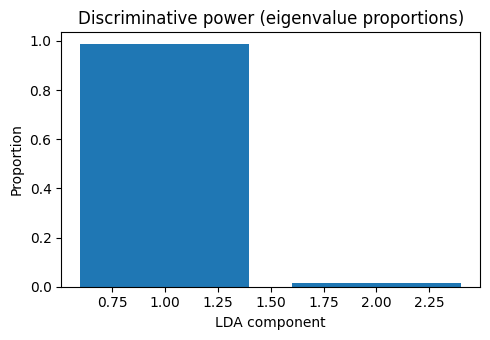

In [6]:
lam = np.maximum(evals, 0)
prop = lam / np.sum(lam) if np.sum(lam)>0 else lam
fig = plt.figure(figsize=(5,3.5))
plt.bar(range(1,len(lam)+1), prop)
plt.xlabel("LDA component"); plt.ylabel("Proportion")
plt.title("Discriminative power (eigenvalue proportions)")
plt.tight_layout(); plt.show()

## 6) Visualization — LDA Subspace

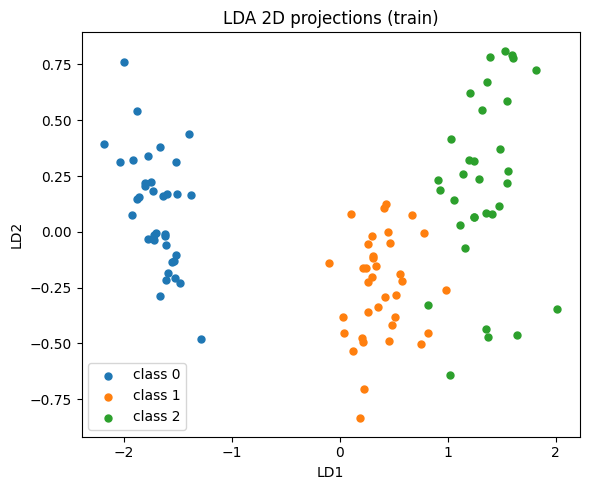

In [7]:
fig = plt.figure(figsize=(6,5))
if Z_tr.shape[1] == 1:
    for c in np.unique(y_tr):
        plt.hist(Z_tr[y_tr==c,0], bins=20, alpha=0.5, label=f"class {c}")
    plt.xlabel("LD1"); plt.title("LDA 1D projections (train)"); plt.legend()
else:
    for c in np.unique(y_tr):
        plt.scatter(Z_tr[y_tr==c,0], Z_tr[y_tr==c,1], s=25, label=f"class {c}")
    plt.xlabel("LD1"); plt.ylabel("LD2"); plt.title("LDA 2D projections (train)"); plt.legend()
plt.tight_layout(); plt.show()

## 7) Plug‑in LDA Classifier (Shared Covariance Gaussian Discriminant)

Assume class-conditional Gaussians with **shared covariance** `Σ` and different means `μ_c`. Discriminant for class `c`:  
$ g_c(x) = x^T Σ^{-1} μ_c - \tfrac{1}{2} μ_c^T Σ^{-1} μ_c + \log π_c $.  
We estimate `μ_c`, `Σ` and priors `π_c = n_c / n` from training data.

In [8]:
class LDAClassifier:
    def __init__(self, reg=1e-6):
        self.reg = reg
        self.means_ = None
        self.cov_ = None
        self.priors_ = None
        self.inv_ = None

    def fit(self, X, y):
        classes = np.unique(y)
        means, counts = class_stats(X, y)
        cov = np.zeros((X.shape[1], X.shape[1]))
        for c in classes:
            Xc = X[y==c]; diff = Xc - means[c]
            cov += diff.T @ diff
        cov /= (len(y) - len(classes))
        cov += self.reg*np.eye(cov.shape[0])
        self.means_ = means
        self.cov_ = cov
        self.inv_ = np.linalg.inv(cov)
        self.priors_ = counts / counts.sum()
        return self

    def decision_function(self, X):
        # g_c(x) = x^T inv Σ μ_c - 0.5 μ_c^T inv Σ μ_c + log π_c
        G = []
        for c in range(self.means_.shape[0]):
            mc = self.means_[c]
            term = X @ (self.inv_ @ mc) - 0.5*(mc @ self.inv_ @ mc) + np.log(self.priors_[c]+1e-300)
            G.append(term)
        return np.vstack(G).T  # (n, C)

    def predict(self, X):
        G = self.decision_function(X)
        return np.argmax(G, axis=1)

lda = LDAClassifier(reg=1e-6).fit(X_tr, y_tr)
yhat_tr = lda.predict(X_tr)
yhat_te = lda.predict(X_te)
acc_tr = (yhat_tr==y_tr).mean()
acc_te = (yhat_te==y_te).mean()
print(f"Accuracy train={acc_tr:.3f}  test={acc_te:.3f}")
print("Confusion (test):\n", confusion_matrix(y_te, yhat_te, n_classes=len(np.unique(y))))

Accuracy train=0.971  test=0.978
Confusion (test):
 [[14  0  0]
 [ 0 13  1]
 [ 0  0 17]]


## 8) Fisher Score — Feature Ranking

For **binary** classes with features `x_j`, Fisher score is  
$ F_j = \frac{(\mu_{1j} - \mu_{0j})^2}{\sigma_{1j}^2 + \sigma_{0j}^2} $.  
A common **multiclass** generalization uses between/within variances:  
$ F_j = \frac{\sum_c n_c (\mu_{cj}-\mu_j)^2}{\sum_c n_c \sigma_{cj}^2} $.

Fisher scores (multiclass) sorted:
petal length (cm)          F=15.2036
petal width (cm)           F=14.1315
sepal length (cm)          F=1.5346
sepal width (cm)           F=0.7220


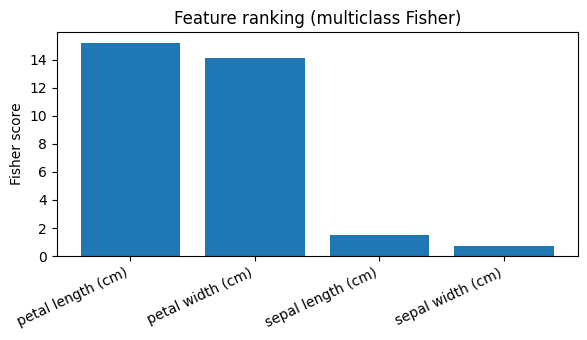

In [9]:
def fisher_score_binary(X, y):
    classes = np.unique(y)
    assert len(classes)==2
    c0, c1 = classes
    X0 = X[y==c0]; X1 = X[y==c1]
    mu0 = X0.mean(axis=0); mu1 = X1.mean(axis=0)
    v0 = X0.var(axis=0, ddof=1); v1 = X1.var(axis=0, ddof=1)
    return (mu1 - mu0)**2 / (v1 + v0 + 1e-12)

def fisher_score_multiclass(X, y):
    classes = np.unique(y)
    means, counts = class_stats(X, y)
    mu = np.average(means, axis=0, weights=counts)
    # between (per-feature)
    num = np.zeros(X.shape[1])
    den = np.zeros(X.shape[1])
    for i,c in enumerate(classes):
        Xc = X[y==c]
        num += counts[i]*(means[i]-mu)**2
        den += counts[i]*Xc.var(axis=0, ddof=1)
    return num / (den + 1e-12)

F_multi = fisher_score_multiclass(X_tr, y_tr)
order = np.argsort(F_multi)[::-1]
print("Fisher scores (multiclass) sorted:")
for j in order:
    print(f"{feature_names[j]:25s}  F={F_multi[j]:.4f}")

fig = plt.figure(figsize=(6,3.5))
plt.bar(range(len(F_multi)), F_multi[order])
plt.xticks(range(len(F_multi)), [feature_names[j] for j in order], rotation=25, ha='right')
plt.ylabel("Fisher score"); plt.title("Feature ranking (multiclass Fisher)")
plt.tight_layout(); plt.show()

## 9) Ablation — Classify with only top‑1 Fisher feature vs. full LDA

As a sanity check, train a 1D Gaussian-naive classifier on the single best Fisher feature and compare accuracy with LDA.

In [10]:
top1 = order[0]
Xtr1 = X_tr[:, [top1]]
Xte1 = X_te[:, [top1]]

class Naive1D:
    def fit(self, X, y):
        classes = np.unique(y)
        self.means = []; self.vars = []; self.priors = []
        for c in classes:
            Xc = X[y==c, 0]
            self.means.append(Xc.mean()); self.vars.append(Xc.var(ddof=1)); self.priors.append(len(Xc)/len(X))
        self.means = np.array(self.means); self.vars = np.array(self.vars); self.priors = np.array(self.priors)
        return self
    def predict(self, X):
        # Gaussian log-likelihood for each class
        g = []
        for m,v,pi in zip(self.means, self.vars, self.priors):
            v = max(v, 1e-6)
            g.append(-0.5*np.log(2*np.pi*v) - (X[:,0]-m)**2/(2*v) + np.log(pi+1e-300))
        return np.argmax(np.vstack(g).T, axis=1)

nb1 = Naive1D().fit(Xtr1, y_tr)
yhat1 = nb1.predict(Xte1)
acc1 = (yhat1==y_te).mean()
print(f"Top-1 feature ({feature_names[top1]}) naive accuracy (test): {acc1:.3f}")
print(f"LDA accuracy (test): {acc_te:.3f}")

Top-1 feature (petal length (cm)) naive accuracy (test): 0.933
LDA accuracy (test): 0.978


## 10) Save Artifacts & Download

In [11]:
import os, json as _json
os.makedirs("artifacts", exist_ok=True)

np.savez("artifacts/lda_fisher_from_scratch.npz",
         X=X, y=y, feature_names=np.array(feature_names, dtype=object),
         X_tr=X_tr, X_te=X_te, y_tr=y_tr, y_te=y_te,
         W=W, evals=evals, Z_tr=Z_tr, Z_te=Z_te,
         lda_means=lda.means_, lda_cov=lda.cov_, lda_priors=lda.priors_,
         fisher_scores=F_multi, fisher_order=order)

with open("artifacts/summary.json","w") as f:
    _json.dump({
        "test_accuracy_lda": float(acc_te),
        "confusion_test": confusion_matrix(y_te, yhat_te, n_classes=len(np.unique(y))).tolist(),
        "fisher_ranking": [feature_names[j] for j in order],
        "lda_eigenvalues": evals.tolist()
    }, f, indent=2)

print("Artifacts:", os.listdir("artifacts"))

Artifacts: ['lda_fisher_from_scratch.npz', 'summary.json']


In [12]:
# Colab download helper
import shutil
from pathlib import Path
try:
    from google.colab import files  # type: ignore
    if Path('artifacts').exists():
        shutil.make_archive('artifacts', 'zip', 'artifacts')
        files.download('artifacts.zip')
    else:
        print('No artifacts folder found.')
except Exception as e:
    print('Colab download helper not available in this environment:', e)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 11) Exercises & Extensions

- Add a **regularized LDA** variant (shrinkage of `Σ` toward diagonal).
- Compare **QDA** (class-specific covariances) vs. LDA.
- Implement **one-vs-rest Fisher LDA** and compare to multiclass eigen-solution.
- Evaluate on non-Gaussian data; test robustness to class imbalance.
